Load & Clean Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [2]:
# Load the three CSV files
sales = pd.read_csv("sales data-set.csv")
features = pd.read_csv("Features data set.csv")
stores = pd.read_csv("stores data-set.csv")

print("Sales Data Shape:", sales.shape)
print("\nSales Columns:\n", sales.columns.tolist())
print("\nFirst few rows of sales:")
print(sales.head())

print("\n" + "="*60)
print("Features Data Shape:", features.shape)
print("\nFeatures Columns:\n", features.columns.tolist())
print("\nFirst few rows of features:")
print(features.head())

print("\n" + "="*60)
print("Stores Data Shape:", stores.shape)
print("\nStores Columns:\n", stores.columns.tolist())
print("\nFirst few rows of stores:")
print(stores.head())


Sales Data Shape: (421570, 5)

Sales Columns:
 ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

First few rows of sales:
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  05/02/2010      24924.50      False
1      1     1  12/02/2010      46039.49       True
2      1     1  19/02/2010      41595.55      False
3      1     1  26/02/2010      19403.54      False
4      1     1  05/03/2010      21827.90      False

Features Data Shape: (8190, 12)

Features Columns:
 ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

First few rows of features:
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  05/02/2010        42.31       2.572        NaN        NaN   
1      1  12/02/2010        38.51       2.548        NaN        NaN   
2      1  19/02/2010        39.93       2.514        NaN        NaN   
3      1  26/02/2010        46.63       2.561 

In [4]:
# Convert Date columns to datetime with correct format
sales["Date"] = pd.to_datetime(sales["Date"], format="%d/%m/%Y")
features["Date"] = pd.to_datetime(features["Date"], format="%d/%m/%Y")

# Sort by Store and Date
sales = sales.sort_values(["Store", "Date"])
features = features.sort_values(["Store", "Date"])

# Merge sales with features
data = sales.merge(features, on=["Store", "Date"], how="left")

# Merge with store information
data = data.merge(stores, on="Store", how="left")

print("Merged Data Shape:", data.shape)
print("\nMerged Data Info:")
print(data.info())
print("\nFirst few rows:")
print(data.head())

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())


Merged Data Shape: (421570, 17)

Merged Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  IsHoliday_y   421

In [5]:
# Fill missing numeric values with median
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

print("Missing values after imputation:")
print(data.isnull().sum())


Missing values after imputation:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday_x     0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday_y     0
Type            0
Size            0
dtype: int64


Analyze Seasonality

In [6]:
# Choose Store 1, Department 1
store_id = 1
dept_id = 1

# Filter data
ts_data = data[(data["Store"] == store_id) & (data["Dept"] == dept_id)].copy()
ts_data = ts_data.sort_values("Date").reset_index(drop=True)

# Extract time series
time_series = ts_data[["Date", "Weekly_Sales"]].set_index("Date")["Weekly_Sales"]

print(f"Time Series for Store {store_id}, Department {dept_id}")
print(f"Shape: {time_series.shape}")
print(f"Date Range: {time_series.index.min()} to {time_series.index.max()}")
print(f"\nBasic Statistics:")
print(time_series.describe())


Time Series for Store 1, Department 1
Shape: (143,)
Date Range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00

Basic Statistics:
count      143.000000
mean     22513.322937
std       9854.349032
min      14537.370000
25%      16494.630000
50%      18535.480000
75%      23214.215000
max      57592.120000
Name: Weekly_Sales, dtype: float64


Visualize Original Time Series

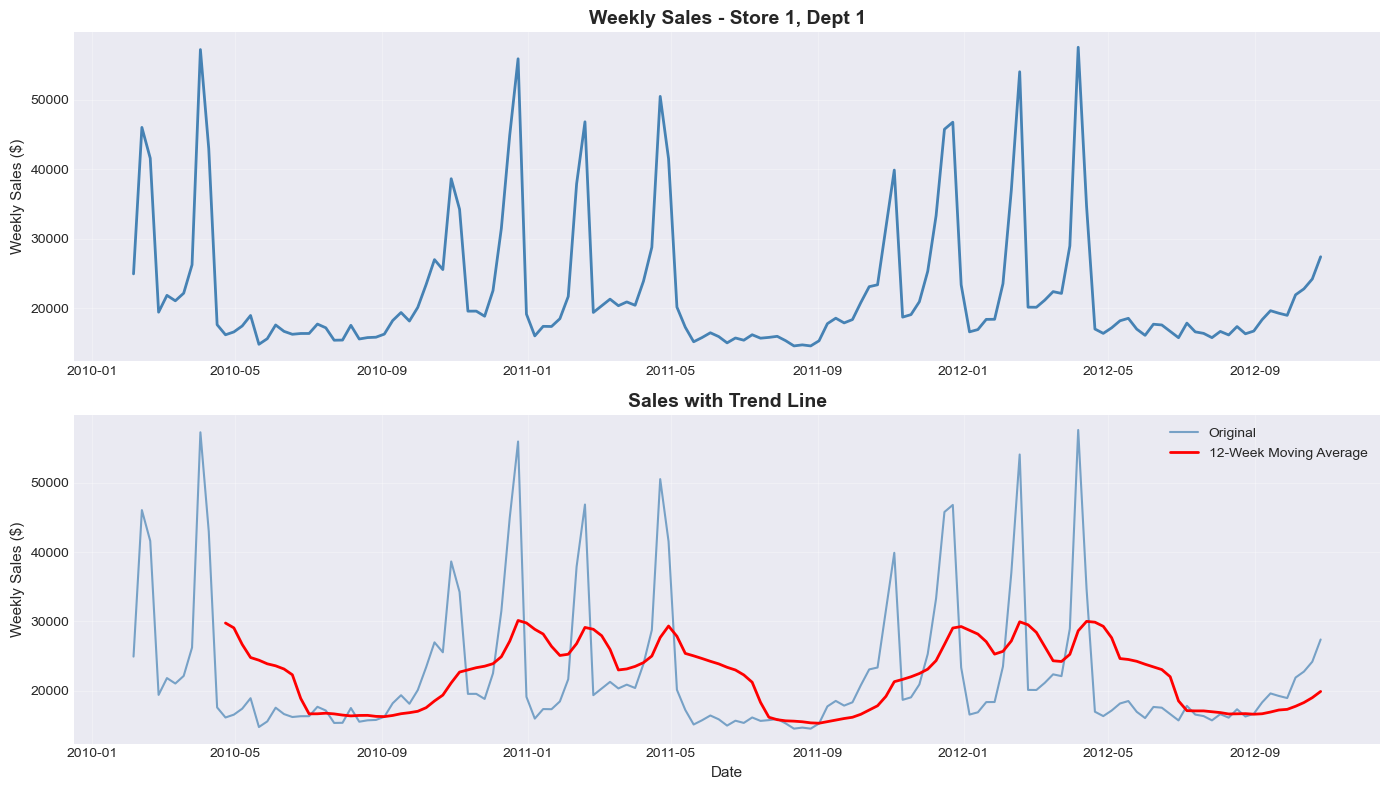

In [7]:
# Plot the original sales data
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full time series
axes[0].plot(time_series.index, time_series.values, linewidth=2, color="steelblue")
axes[0].set_title(f"Weekly Sales - Store {store_id}, Dept {dept_id}", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Weekly Sales ($)", fontsize=11)
axes[0].grid(True, alpha=0.3)

# Rolling mean to see trend
rolling_mean = time_series.rolling(window=12).mean()  # 12-week rolling average
axes[1].plot(time_series.index, time_series.values, label="Original", alpha=0.7, color="steelblue")
axes[1].plot(rolling_mean.index, rolling_mean.values, label="12-Week Moving Average", 
             linewidth=2, color="red")
axes[1].set_title("Sales with Trend Line", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Date", fontsize=11)
axes[1].set_ylabel("Weekly Sales ($)", fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Seasonality Analysis

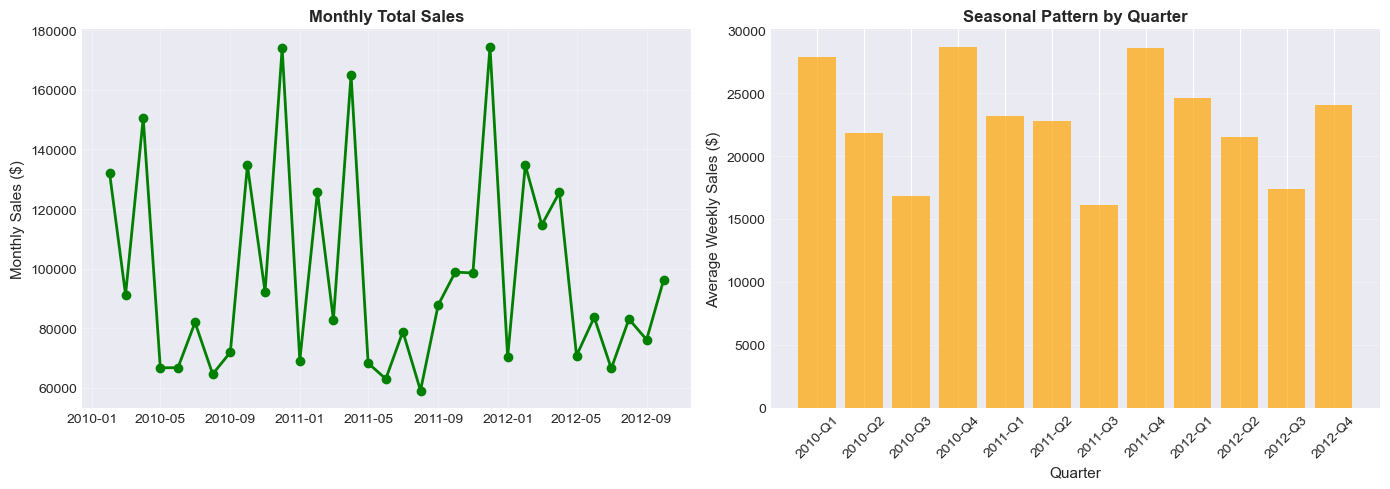


Quarterly Average Sales:
    Year  Quarter  Weekly_Sales YearQuarter
0   2010        1  27900.027500     2010-Q1
1   2010        2  21842.431538     2010-Q2
2   2010        3  16800.545385     2010-Q3
3   2010        4  28627.843571     2010-Q4
4   2011        1  23144.380000     2011-Q1
5   2011        2  22791.326154     2011-Q2
6   2011        3  16119.613571     2011-Q3
7   2011        4  28604.339231     2011-Q4
8   2012        1  24582.245385     2012-Q1
9   2012        2  21541.510769     2012-Q2
10  2012        3  17357.866154     2012-Q3
11  2012        4  24061.140000     2012-Q4


In [8]:
# Aggregate by month to see seasonality
monthly_sales = ts_data.set_index("Date")["Weekly_Sales"].resample("MS").sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly sales
axes[0].plot(monthly_sales.index, monthly_sales.values, marker="o", linewidth=2, color="green")
axes[0].set_title("Monthly Total Sales", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Monthly Sales ($)", fontsize=11)
axes[0].grid(True, alpha=0.3)

# Seasonal pattern - by quarter/season
ts_data['Year'] = ts_data['Date'].dt.year
ts_data['Quarter'] = ts_data['Date'].dt.quarter

quarterly_avg = ts_data.groupby(['Year', 'Quarter'])['Weekly_Sales'].mean().reset_index()
quarterly_avg['YearQuarter'] = quarterly_avg['Year'].astype(str) + '-Q' + quarterly_avg['Quarter'].astype(str)

axes[1].bar(range(len(quarterly_avg)), quarterly_avg['Weekly_Sales'], color="orange", alpha=0.7)
axes[1].set_xlabel("Quarter", fontsize=11)
axes[1].set_ylabel("Average Weekly Sales ($)", fontsize=11)
axes[1].set_title("Seasonal Pattern by Quarter", fontsize=12, fontweight="bold")
axes[1].set_xticks(range(len(quarterly_avg)))
axes[1].set_xticklabels(quarterly_avg['YearQuarter'], rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nQuarterly Average Sales:")
print(quarterly_avg)


Train-Test Split

Train set size: 114 weeks
Test set size: 29 weeks
Train date range: 2010-02-05 00:00:00 to 2012-04-06 00:00:00
Test date range: 2012-04-13 00:00:00 to 2012-10-26 00:00:00


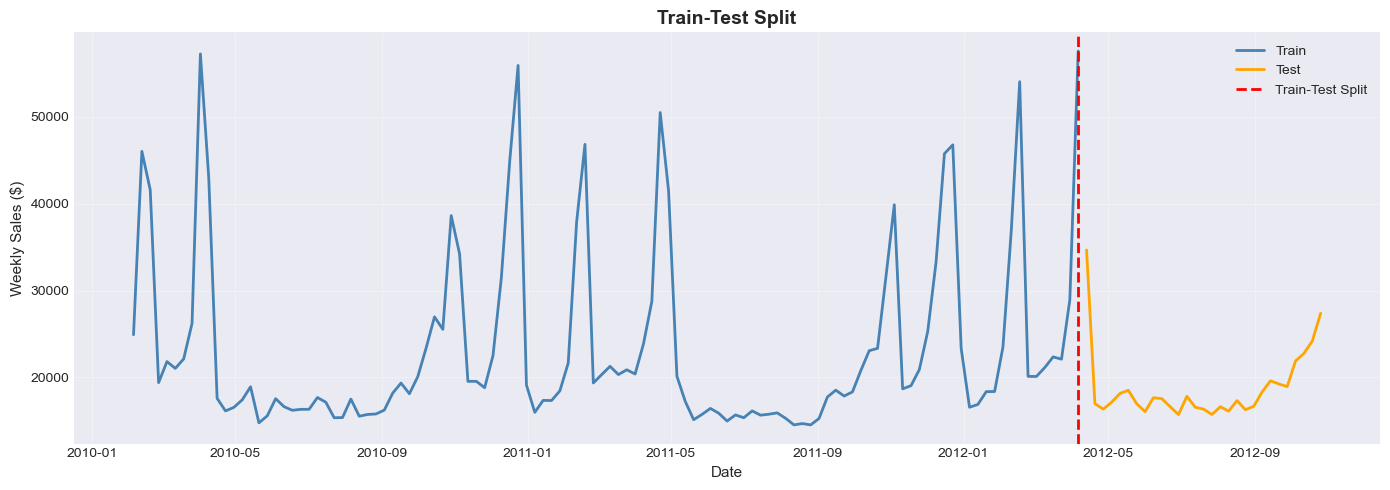

In [9]:
# Split data: 80% train, 20% test
train_size = int(len(time_series) * 0.8)
train = time_series[:train_size]
test = time_series[train_size:]

print(f"Train set size: {len(train)} weeks")
print(f"Test set size: {len(test)} weeks")
print(f"Train date range: {train.index.min()} to {train.index.max()}")
print(f"Test date range: {test.index.min()} to {test.index.max()}")

# Visualize split
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, label="Train", linewidth=2, color="steelblue")
plt.plot(test.index, test.values, label="Test", linewidth=2, color="orange")
plt.axvline(x=train.index[-1], color="red", linestyle="--", linewidth=2, label="Train-Test Split")
plt.title("Train-Test Split", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=11)
plt.ylabel("Weekly Sales ($)", fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ARIMA Model

In [10]:
# Fit ARIMA model: ARIMA(1, 1, 1) - you can tune p, d, q values
# p=order of AR, d=differencing, q=order of MA

model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
results = model.fit(disp=False)

print(results.summary())


                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1190.659
Date:                Mon, 08 Dec 2025   AIC                           2387.317
Time:                        12:24:57   BIC                           2395.500
Sample:                    02-05-2010   HQIC                          2390.638
                         - 04-06-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5879      0.056     10.537      0.000       0.479       0.697
ma.L1         -0.9999      0.087    -11.542      0.000      -1.170      -0.830
sigma2      8.079e+07   1.08e-09   7.46e+16      0.0

Make Predictions

In [11]:
# Forecast on test set
predictions = results.get_forecast(steps=len(test))
forecast = predictions.predicted_mean
confidence_interval = predictions.conf_int()

print(f"Predictions shape: {forecast.shape}")
print(f"\nFirst 5 predicted values:")
print(forecast.head())

# Calculate errors
rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"\nModel Performance on Test Set:")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE: ${mae:,.2f}")
print(f"MAPE: {mape:.2f}%")


Predictions shape: (29,)

First 5 predicted values:
2012-04-13    43502.314801
2012-04-20    35218.872912
2012-04-27    30349.010727
2012-05-04    27486.003054
2012-05-11    25802.831614
Freq: W-FRI, Name: predicted_mean, dtype: float64

Model Performance on Test Set:
RMSE: $7,474.89
MAE: $6,642.22
MAPE: 37.75%


Visualize Actual vs Predicted

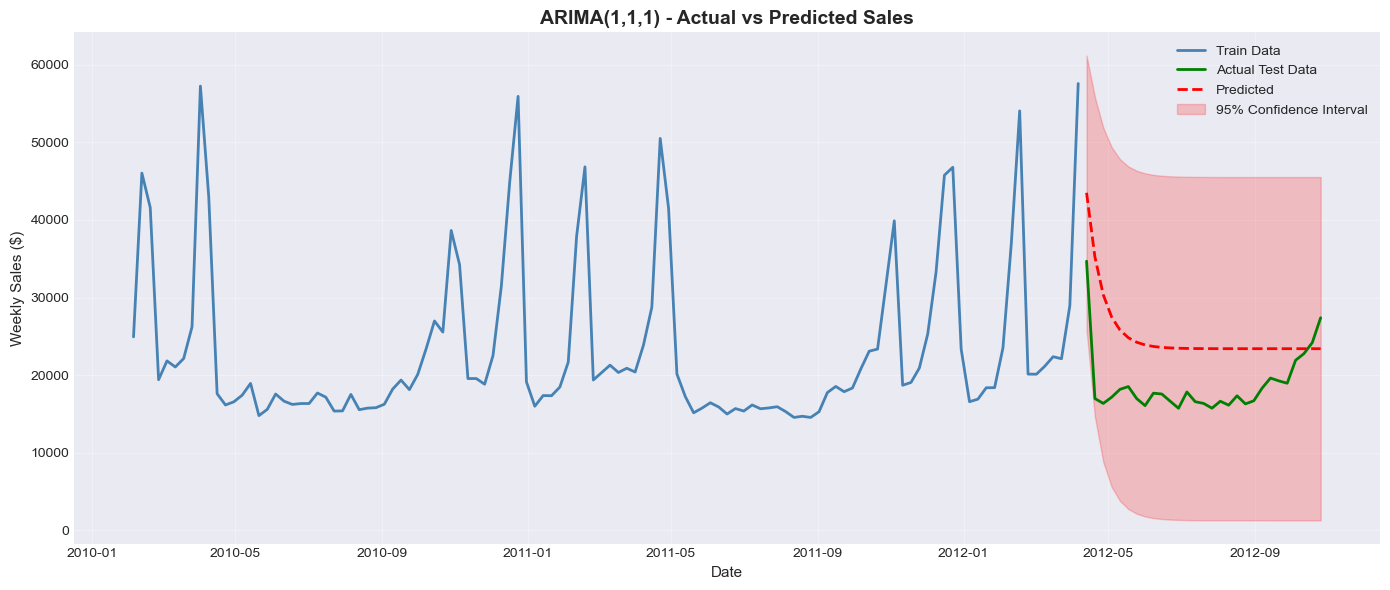

In [12]:
# Plot actual vs predicted
plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, label="Train Data", linewidth=2, color="steelblue")
plt.plot(test.index, test.values, label="Actual Test Data", linewidth=2, color="green")
plt.plot(test.index, forecast.values, label="Predicted", linewidth=2, color="red", linestyle="--")

# Confidence interval
plt.fill_between(test.index, 
                  confidence_interval.iloc[:, 0], 
                  confidence_interval.iloc[:, 1], 
                  alpha=0.2, color="red", label="95% Confidence Interval")

plt.title(f"ARIMA(1,1,1) - Actual vs Predicted Sales", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=11)
plt.ylabel("Weekly Sales ($)", fontsize=11)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Forecast Future Sales (Next 12 Weeks)

In [13]:
# Refit model on entire dataset for future forecast
final_model = SARIMAX(time_series, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
final_results = final_model.fit(disp=False)

# Forecast next 12 weeks
future_forecast = final_results.get_forecast(steps=12)
future_pred = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

# Create future date index
last_date = time_series.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=12, freq="W")

print("Future 12-Week Sales Forecast:")
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Sales': future_pred.values,
    'Lower_CI': future_ci.iloc[:, 0].values,
    'Upper_CI': future_ci.iloc[:, 1].values
})
print(forecast_df)


Future 12-Week Sales Forecast:
         Date  Predicted_Sales     Lower_CI      Upper_CI
0  2012-11-04     25185.325186  9088.905403  41281.744969
1  2012-11-11     23917.437463  5296.507653  42538.367274
2  2012-11-18     23188.554967  3775.574235  42601.535698
3  2012-11-25     22769.535455  3084.864855  42454.206055
4  2012-12-02     22528.649782  2745.322380  42311.977184
5  2012-12-09     22390.169578  2568.787442  42211.551713
6  2012-12-16     22310.560165  2473.425063  42147.695267
7  2012-12-23     22264.794356  2420.621303  42108.967408
8  2012-12-30     22238.484536  2390.931635  42086.037437
9  2013-01-06     22223.359564  2374.083673  42072.635454
10 2013-01-13     22214.664529  2364.470818  42064.858240
11 2013-01-20     22209.665933  2358.968605  42060.363261


Visualize Future Forecast

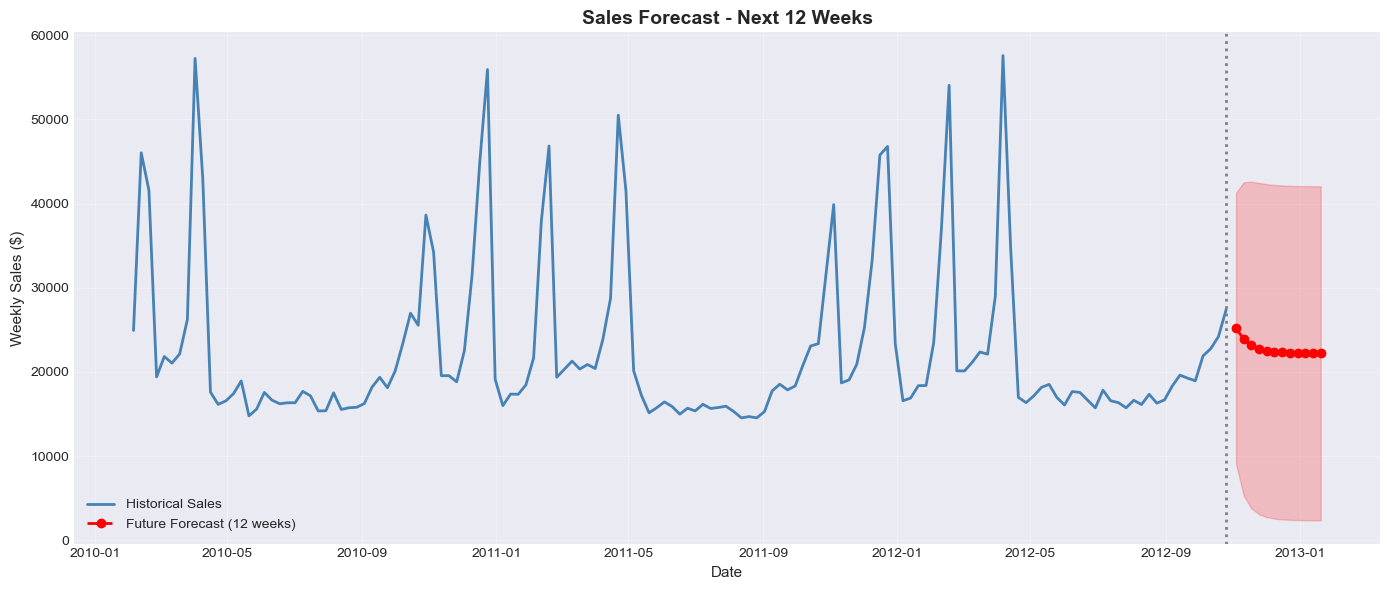

In [14]:
# Plot historical data + future forecast
plt.figure(figsize=(14, 6))
plt.plot(time_series.index, time_series.values, label="Historical Sales", linewidth=2, color="steelblue")
plt.plot(future_dates, future_pred.values, label="Future Forecast (12 weeks)", 
         linewidth=2, color="red", linestyle="--", marker="o")

# Confidence interval
plt.fill_between(future_dates, 
                  future_ci.iloc[:, 0], 
                  future_ci.iloc[:, 1], 
                  alpha=0.2, color="red")

plt.title("Sales Forecast - Next 12 Weeks", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=11)
plt.ylabel("Weekly Sales ($)", fontsize=11)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.axvline(x=time_series.index[-1], color="gray", linestyle=":", linewidth=2, label="Forecast Start")
plt.tight_layout()
plt.show()


Inventory & Restocking Recommendations

In [15]:
# Analyze peaks and lows from forecast
forecast_combined = pd.concat([time_series, pd.Series(future_pred.values, index=future_dates)])

# Find peak and low periods
peak_sales = forecast_combined.max()
low_sales = forecast_combined.min()
avg_sales = forecast_combined.mean()
std_sales = forecast_combined.std()

print("="*60)
print("INVENTORY & RESTOCKING RECOMMENDATIONS")
print("="*60)
print(f"\nHistorical & Forecasted Sales Summary:")
print(f"Peak Sales: ${peak_sales:,.2f}")
print(f"Low Sales: ${low_sales:,.2f}")
print(f"Average Sales: ${avg_sales:,.2f}")
print(f"Std Deviation: ${std_sales:,.2f}")

# Recommendations based on forecast
print(f"\n KEY INSIGHTS:")
print(f"- Highest forecasted weekly sales: ${future_pred.max():,.2f}")
print(f"- Lowest forecasted weekly sales: ${future_pred.min():,.2f}")
print(f"- Average forecasted sales: ${future_pred.mean():,.2f}")

# Peak and low weeks
peak_week_idx = future_pred.idxmax()
low_week_idx = future_pred.idxmin()

print(f"\n PEAK PERIOD:")
print(f"   Week of {peak_week_idx.date()}: ${future_pred.max():,.2f}")
print(f"   ➜ INCREASE INVENTORY by 30-50%")

print(f"\n LOW PERIOD:")
print(f"   Week of {low_week_idx.date()}: ${future_pred.min():,.2f}")
print(f"   ➜ REDUCE INVENTORY by 20-30% to avoid overstocking")

print(f"\n RESTOCKING STRATEGY:")
print(f"   1. Stock up 2-3 weeks BEFORE peak periods")
print(f"   2. During peak: Monitor stock daily, increase ordering frequency")
print(f"   3. Clear excess inventory during low periods with promotions")
print(f"   4. Maintain safety stock at: ${avg_sales + std_sales:,.2f} (Mean + 1 Std)")

# Create recommendation table
recommendations = pd.DataFrame({
    'Period': ['Peak Period', 'Average Period', 'Low Period'],
    'Expected Sales': [f"${future_pred.max():,.0f}", f"${future_pred.mean():,.0f}", f"${future_pred.min():,.0f}"],
    'Inventory Action': ['Increase 30-50%', 'Maintain Standard', 'Reduce 20-30%'],
    'Ordering Frequency': ['Daily/Bi-daily', '2-3 times/week', 'Once per week']
})

print("\n" + "="*60)
print("INVENTORY ACTION PLAN:")
print("="*60)
print(recommendations.to_string(index=False))


INVENTORY & RESTOCKING RECOMMENDATIONS

Historical & Forecasted Sales Summary:
Peak Sales: $57,592.12
Low Sales: $14,537.37
Average Sales: $22,534.49
Std Deviation: $9,466.07

 KEY INSIGHTS:
- Highest forecasted weekly sales: $25,185.33
- Lowest forecasted weekly sales: $22,209.67
- Average forecasted sales: $22,786.77

 PEAK PERIOD:
   Week of 2012-11-02: $25,185.33
   ➜ INCREASE INVENTORY by 30-50%

 LOW PERIOD:
   Week of 2013-01-18: $22,209.67
   ➜ REDUCE INVENTORY by 20-30% to avoid overstocking

 RESTOCKING STRATEGY:
   1. Stock up 2-3 weeks BEFORE peak periods
   2. During peak: Monitor stock daily, increase ordering frequency
   3. Clear excess inventory during low periods with promotions
   4. Maintain safety stock at: $32,000.56 (Mean + 1 Std)

INVENTORY ACTION PLAN:
        Period Expected Sales  Inventory Action Ordering Frequency
   Peak Period        $25,185   Increase 30-50%     Daily/Bi-daily
Average Period        $22,787 Maintain Standard     2-3 times/week
    Low Per